In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

In [ ]:
ig = np.load('data/IGValues.npz', allow_pickle=True)
print(ig.keys())

KeysView(<numpy.lib.npyio.NpzFile object at 0x11891fb80>)


In [3]:
ig_tumor = ig['tumor'].item()
ig_tumor

{'feature_attr': array([[1.7125297e-03, 1.6110505e-03, 1.7435092e-03, ..., 1.2276231e-03,
         1.3494258e-03, 1.1425167e-03],
        [1.6046937e-03, 1.7152209e-03, 1.5789932e-03, ..., 9.1629312e-04,
         1.0363124e-03, 8.1678800e-04],
        [1.3037969e-03, 1.5039445e-03, 1.1845498e-03, ..., 7.9497189e-04,
         8.6800801e-04, 6.0635846e-04],
        ...,
        [7.9457794e-05, 8.4538595e-05, 8.3284569e-05, ..., 3.7459678e-05,
         7.2382478e-05, 4.5407964e-05],
        [6.7511573e-05, 4.2371674e-05, 4.9574992e-05, ..., 2.7433323e-06,
         3.0288345e-05, 1.4641711e-05],
        [5.6670375e-05, 5.1311086e-05, 4.4248427e-05, ..., 8.4141629e-06,
         3.4402838e-05, 2.7396922e-05]], dtype=float32),
 'dela': array([2.5095716e-03, 2.2930279e-03, 2.0159036e-03, ..., 1.6350928e-04,
        1.2171711e-04, 4.2405678e-05], dtype=float32)}

In [4]:
ig_tumor_attr = ig_tumor['feature_attr']
ig_tumor_attr.shape

(1495, 52)

In [ ]:
tumor_data = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
X_test = 1 - tumor_data['zspec']
tumor_inds = tumor_data['voxelInds_tumor']

In [6]:
X_test = X_test[tumor_inds]
print(X_test.shape)

(1495, 52)


In [7]:
offsets = np.linspace(-5,5,51)
offsets = np.concatenate((offsets,np.array(0).reshape(1,)))
offsets = np.sort(np.round(offsets,3))
print(offsets)

[-5.  -4.8 -4.6 -4.4 -4.2 -4.  -3.8 -3.6 -3.4 -3.2 -3.  -2.8 -2.6 -2.4
 -2.2 -2.  -1.8 -1.6 -1.4 -1.2 -1.  -0.8 -0.6 -0.4 -0.2  0.   0.   0.2
  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6  2.8  3.
  3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5. ]


## Plot the integrated gradients for feature importance

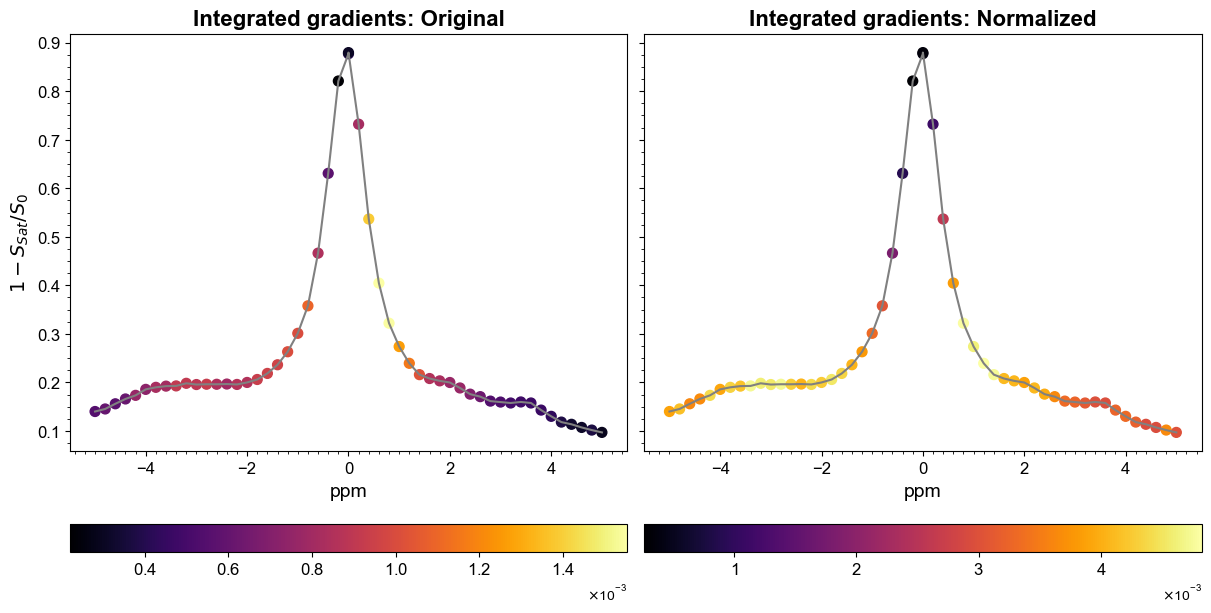

In [8]:
# shap.summary_plot(ig_tumor_attr, X_test, feature_names=offsets, max_display=10)
X_test_mean = np.mean(X_test, axis=0)
ig_mean = np.mean(ig_tumor_attr, axis=0)
# ig_norm = (ig_mean - np.min(ig_mean)) / (np.max(ig_mean) - np.min(ig_mean))
ig_norm = ig_mean / X_test_mean

# Create integrated gradient plot
fig, ax = plt.subplots(1,2,figsize=(12,6),layout='constrained', sharey=True)
ax[0].plot(offsets, X_test_mean, c='gray')
scatter1 = ax[0].scatter(offsets, X_test_mean, c=ig_mean, cmap='inferno', 
                     s=50)

ax[1].plot(offsets, X_test_mean, c='gray')
scatter2 = ax[1].scatter(offsets, X_test_mean, c=ig_norm, cmap='inferno', 
                         s=50)

for axes in ax.flat:
    axes.set_xlabel('ppm', fontsize=14)
    axes.xaxis.set_minor_locator(AutoMinorLocator(10))
    axes.yaxis.set_minor_locator(AutoMinorLocator(4))
    axes.tick_params(which='both', labelsize=12)

ax[0].set_ylabel(r'$1- S_{Sat}/S_0$', fontsize=14)
ax[0].set_title('Integrated gradients: Original', fontsize=16, fontweight='bold')
ax[1].set_title('Integrated gradients: Normalized', fontsize=16, fontweight='bold')

# Plot colorbar and format
cbar1 = plt.colorbar(scatter1, ax = ax[0], location='bottom')
cbar1.ax.tick_params(labelsize=12)
cbar1.formatter = ticker.ScalarFormatter(useMathText=True) # Use math text for 10^x
cbar1.formatter.set_powerlimits((0, 0)) # Force scientific notation for all values
cbar1.update_ticks()

cbar2 = plt.colorbar(scatter2, ax = ax[1], location='bottom')
cbar2.ax.tick_params(labelsize=12)
cbar2.formatter = ticker.ScalarFormatter(useMathText=True) # Use math text for 10^x
cbar2.formatter.set_powerlimits((0, 0)) # Force scientific notation for all values
cbar2.update_ticks()

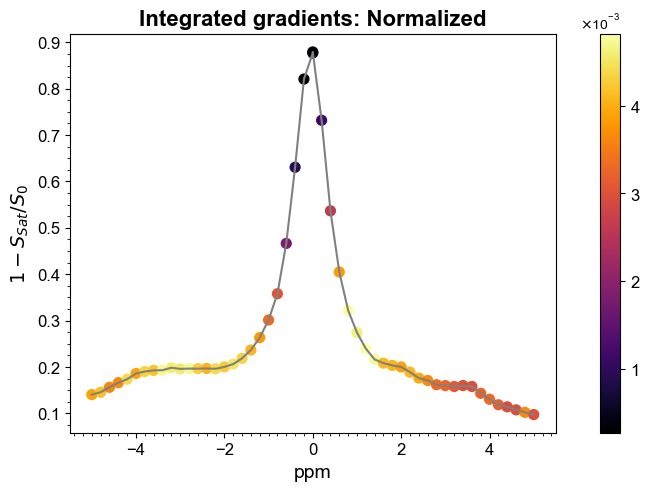

In [15]:
X_test_mean = np.mean(X_test, axis=0)
ig_mean = np.mean(ig_tumor_attr, axis=0)
ig_norm = ig_mean / X_test_mean

# Create integrated gradient plot
fig, ax = plt.subplots(layout='constrained')

ax.plot(offsets, X_test_mean, c='gray')
scatter = ax.scatter(offsets, X_test_mean, c=ig_norm, cmap='inferno', 
                         s=50)

ax.set_xlabel('ppm', fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.tick_params(which='both', labelsize=12)

ax.set_ylabel(r'$1- S_{Sat}/S_0$', fontsize=14)
ax.set_title('Integrated gradients: Normalized', fontsize=16, fontweight='bold')

cbar = plt.colorbar(scatter, ax = ax, location='right')
cbar.ax.tick_params(labelsize=12)
cbar.formatter = ticker.ScalarFormatter(useMathText=True) # Use math text for 10^x
cbar.formatter.set_powerlimits((0, 0)) # Force scientific notation for all values
cbar.update_ticks()

In [11]:
top26_inds = np.argsort(ig_norm)[::-1][:26]
print("Top 26 feature offsets (ppm):", np.sort(offsets[top26_inds]))

Top 26 feature offsets (ppm): [-5.  -4.8 -4.2 -4.  -3.8 -3.6 -3.4 -3.2 -3.  -2.8 -2.6 -2.4 -2.2 -2.
 -1.8 -1.6 -1.4  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4]


In [12]:
top8_inds = np.argsort(ig_norm)[::-1][:8]
print("Top 8 feature offsets (ppm):", np.sort(offsets[top8_inds]))

Top 8 feature offsets (ppm): [-3.4 -3.2 -3.  -2.8  0.8  1.   1.2  1.4]


## Plot the SHAP values from IF

In [ ]:
# shap_vals_if = np.load('ShapValues_IF.npz')
shap_vals_if = np.load('data/ShapValues_IF.npz')
shap_vals_if = shap_vals_if['shap_values']

In [16]:
tumor_data = np.load('Data/RatTumorData_postGd_val_test.npz', allow_pickle=True)
X_test = tumor_data['Test'].item()['X_test']
print(X_test.shape)

(9320, 52)


In [17]:
selected_inds = tumor_data['Test'].item()['y_test']
selected_inds = np.where(selected_inds == 1)[0]
print(len(selected_inds))

648


In [18]:
X_test = X_test[selected_inds]

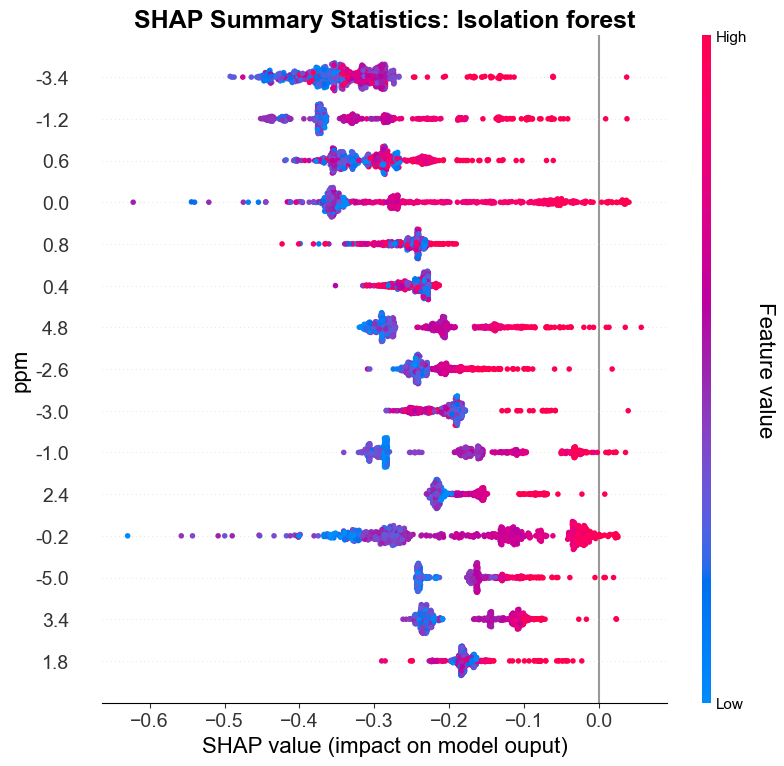

In [ ]:
shap.summary_plot(shap_vals_if.squeeze(), X_test, feature_names=offsets, max_display=15, show=False)
# Get the current Matplotlib axes object
ax = plt.gca()
# Set the y-axis label
ax.set_ylabel("ppm", fontsize=16)
ax.set_xlabel('SHAP value (impact on model ouput)', fontsize=16)
ax.tick_params(which='both', labelsize=14)
ax.set_title('SHAP Summary Statistics: Isolation forest', fontsize=18, fontweight='bold')
cbar_ax = plt.gcf().axes[-1]
cbar_ax.set_ylabel("Feature value", rotation=270, labelpad=20, fontsize=16)

In [20]:
shap_vals_if_mean = np.mean(shap_vals_if, axis=0)
inds_shap_if = np.argsort(shap_vals_if_mean)

In [21]:
offsets[inds_shap_if]

array([-3.4, -1.2,  0.6,  0.8,  0. ,  0.4,  4.8, -2.6, -3. , -1. ,  2.4,
       -0.2, -5. ,  3.4,  1.8,  0.2, -4.2,  1. , -0.6, -4.8,  2. ,  3. ,
        1.4,  0. ,  5. , -3.2, -3.8, -3.6, -4.6, -4. ,  2.8,  4.2,  4.6,
        2.6, -2.4, -2.8, -1.6,  3.8, -1.8, -4.4, -0.8,  3.2,  4. ,  3.6,
        1.6, -2. , -1.4, -2.2, -0.4,  1.2,  2.2,  4.4])